# Phase 3 — Tier Analysis: Does utilization predict incident rate?

**Research question:** If we split stations into Low / Medium / High utilization
tiers, do higher-utilization stations have higher incident rates?

**Analytical unit:** One row per station (mean across all observed months).
Aggregating to the station level avoids the confound of the same station
appearing in different tiers from month to month.

**Test stack:**
1. Kruskal-Wallis — non-parametric test for any difference in incident rate
   distribution across the three tiers.
2. Spearman rank correlation — tests the monotone hypothesis (higher utilization
   → higher rate) at the station level.

Missing-data assumption: `missing_is_zero` (2 396 rows, 572 stations).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("src").resolve()))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from data import load_raw, build_panel, apply_missing_data_assumption
from tier_analysis import (
    compute_station_aggregates,
    assign_tertiles,
    tier_summary,
    kruskal_test,
    spearman_test,
)
from plots import setup_style, plot_tier_means

setup_style()
DATA_PATH = Path("data/session_stats.xlsx")


## 1. Load and prepare data

In [2]:
sessions, tasks, incidents = load_raw(DATA_PATH)
panel = build_panel(sessions, tasks, incidents)
panel_zero = apply_missing_data_assumption(panel, "missing_is_zero")
print(f"Panel rows: {len(panel_zero):,}  |  Unique stations: {panel_zero['charging_location_id'].nunique():,}")


Panel rows: 2,396  |  Unique stations: 571


## 2. Aggregate to station level

We collapse the (location, month) panel to one row per station by averaging
utilization and incident rate across all observed months. This smooths
month-to-month variability and gives a stable, single signal per station.

In [3]:
station_df = compute_station_aggregates(panel_zero)
station_df = assign_tertiles(station_df)

print(f"Stations: {len(station_df):,}")
print()
print(station_df["tier"].value_counts().sort_index())


Stations: 571

tier
Low       191
Medium    190
High      190
Name: count, dtype: int64


## 3. Tier summary table

For each tier: count, mean incident rate, median, standard deviation,
bootstrapped 95 % CI on the mean (1 000 resamples, seed = 42),
and the utilization range that defines the tier.

In [4]:
summary = tier_summary(station_df)
display(summary.style
    .format({
        "n": "{:.0f}",
        "mean": "{:.4f}",
        "median": "{:.4f}",
        "std": "{:.4f}",
        "ci_low": "{:.4f}",
        "ci_high": "{:.4f}",
        "util_min": "{:.1f}",
        "util_max": "{:.1f}",
    })
    .set_caption("Table 1. Per-tier descriptive statistics (missing_is_zero assumption)")
)


,n,mean,median,std,ci_low,ci_high,util_min,util_max
tier,,,,,,,,
Low,191,0.1034,0.0556,0.1574,0.0817,0.1269,3.3,82.6
Medium,190,0.1257,0.0828,0.1807,0.1012,0.1516,82.8,161.4
High,190,0.0881,0.0745,0.0857,0.0757,0.1000,162.2,694.8


## 4. Visual comparison: mean incident rate by tier

Each bar shows the per-tier mean; error bars are the 95 % bootstrap CI.

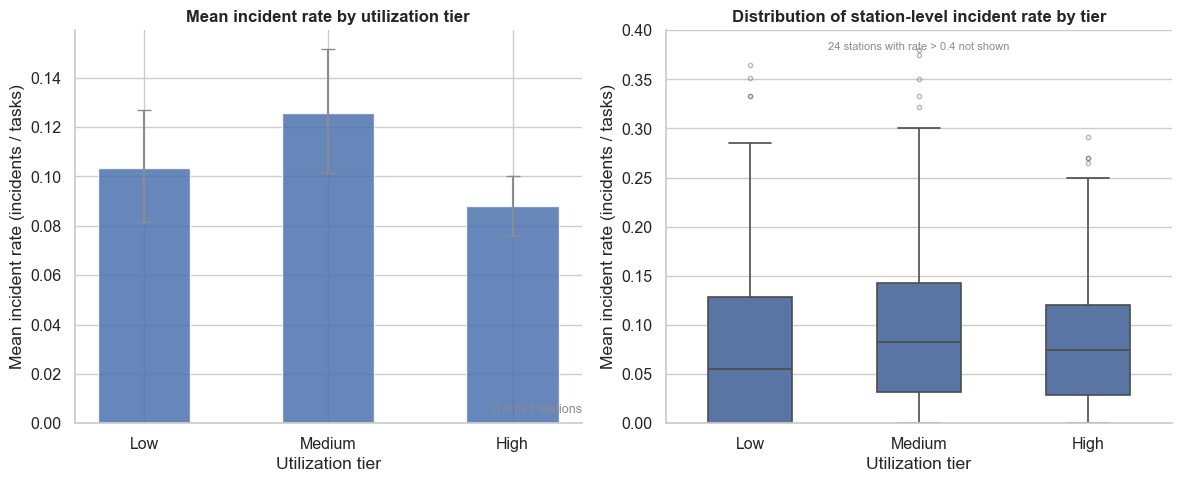

Saved: figures/tier_analysis.png  (24 outlier stations above ylim not shown)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: mean rate by tier with CI error bars
ax = plot_tier_means(summary, ax=axes[0])
# Unobtrusive n annotation in lower-right corner of the bar plot.
ax.annotate(
    "n = 571 stations",
    xy=(1.0, 0.02), xycoords="axes fraction",
    ha="right", va="bottom",
    fontsize=9, color="#8C8C8C",
)

# Right: box plot of per-station mean_incident_rate by tier.
# ylim=(0, 0.4) crops the viewport so IQRs/whiskers are clearly visible.
# Outliers beyond 0.4 exist (max ~1.6) but are excluded from the visible
# range only — the boxplot statistics are computed on all data.
import seaborn as sns
from plots import _PALETTE

order = list(station_df["tier"].cat.categories)
n_outliers = (station_df["mean_incident_rate"] > 0.4).sum()
sns.boxplot(
    data=station_df,
    x="tier",
    y="mean_incident_rate",
    order=order,
    palette=[_PALETTE["primary"]] * 3,
    width=0.5,
    linewidth=1.2,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    ax=axes[1],
)
axes[1].set_ylim(0, 0.4)
axes[1].set_title("Distribution of station-level incident rate by tier",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Utilization tier")
axes[1].set_ylabel("Mean incident rate (incidents / tasks)")
axes[1].annotate(
    f"{n_outliers} stations with rate > 0.4 not shown",
    xy=(0.5, 0.97), xycoords="axes fraction",
    ha="center", va="top",
    fontsize=8, color="#8C8C8C",
)

fig.tight_layout()
fig.savefig("figures/tier_analysis.png")
plt.show()
print(f"Saved: figures/tier_analysis.png  ({n_outliers} outlier stations above ylim not shown)")


## 5. Statistical tests

### 5a. Kruskal-Wallis H-test

Non-parametric test for whether the three tier distributions are identical.
H₀: the three groups come from the same distribution.
Appropriate because incident_rate is right-skewed and zero-inflated.

In [6]:
kw = kruskal_test(station_df)
print(f"Kruskal-Wallis H = {kw['H_statistic']:.4f},  p = {kw['p_value']:.4f}")
print(f"n per tier: {kw['n_per_tier']}")


Kruskal-Wallis H = 5.2125,  p = 0.0738
n per tier: {'Low': 191, 'Medium': 190, 'High': 190}


### 5b. Spearman rank correlation

Tests the monotone hypothesis at the station level (one observation per station).
Using station-level data avoids pseudo-replication that would arise from the raw
(location, month) panel where each station appears up to six times.

In [7]:
sp = spearman_test(station_df)
print(f"Spearman rho = {sp['rho']:.4f},  p = {sp['p_value']:.4f},  n = {sp['n']}")


Spearman rho = 0.0377,  p = 0.3685,  n = 571


## 6. Interpretation

**Tier summary:**

In [8]:
# Print bullets dynamically from computed results
kw_sig   = kw["p_value"] < 0.05
sp_sig   = sp["p_value"] < 0.05
sp_dir   = "positive" if sp["rho"] > 0 else "negative"
rho_mag  = abs(sp["rho"])

low_mean  = summary.loc["Low",  "mean"]
mid_mean  = summary.loc["Medium", "mean"]
high_mean = summary.loc["High", "mean"]

print("Key findings")
print("─" * 60)
print(f"• Low-tier mean rate : {low_mean:.4f}")
print(f"  Mid-tier mean rate : {mid_mean:.4f}")
print(f"  High-tier mean rate: {high_mean:.4f}")
print()
if not kw_sig:
    print(f"• Kruskal-Wallis test is NOT significant (p = {kw['p_value']:.3f}).")
    print("  We cannot reject H₀ that all three tiers share the same distribution.")
else:
    print(f"• Kruskal-Wallis test IS significant (p = {kw['p_value']:.3f}).")
print()
if not sp_sig:
    print(f"• Spearman rho = {sp['rho']:.4f} (p = {sp['p_value']:.3f}): "
          "no significant monotone relationship.")
else:
    print(f"• Spearman rho = {sp['rho']:.4f} (p = {sp['p_value']:.3f}): "
          f"significant {sp_dir} correlation, but rho = {rho_mag:.3f} is weak.")
print()
print("→ Utilization tier does not predict incident rate.")
print("  Dispatch scheduling by tier is not supported by this data.")


Key findings
────────────────────────────────────────────────────────────
• Low-tier mean rate : 0.1034
  Mid-tier mean rate : 0.1257
  High-tier mean rate: 0.0881

• Kruskal-Wallis test is NOT significant (p = 0.074).
  We cannot reject H₀ that all three tiers share the same distribution.

• Spearman rho = 0.0377 (p = 0.369): no significant monotone relationship.

→ Utilization tier does not predict incident rate.
  Dispatch scheduling by tier is not supported by this data.
